### TNCDR-mitigating Qiskit results

Retrieve results on IBM machine, compute exact expectation values using hybrid stabilizers-MPO and execute data-driven error mitigation with these data.

In [41]:
import os, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Qibo related stuff
from qibo import set_backend
from qibo import symbols, hamiltonians

# Qiskit related stuff
from qiskit_ibm_runtime import RuntimeDecoder
from tncdr.targets.ansatze import FloquetAnsatz, TranspiledAnsatz
from tncdr.evolutors.models import HybridSurrogate

In [106]:
# Set Qibo backend, for a double check
set_backend("qibojit", platform="numba")

path = "21q_2l"

[Qibo 0.2.20|INFO|2025-07-23 15:40:38]: Using qibojit (numba) backend on /CPU:0


In [107]:
# Loading results from hardware run
with open(f"{path}/results/tncdr_results.json", "r") as file:
    result = json.load(file, cls=RuntimeDecoder)

values = []
for res in result:
    values.append(res.data.evs)

In [108]:
result.metadata

{'dynamical_decoupling': {'enable': False,
  'sequence_type': 'XX',
  'extra_slack_distribution': 'middle',
  'scheduling_method': 'alap'},
 'twirling': {'enable_gates': False,
  'enable_measure': True,
  'num_randomizations': 'auto',
  'shots_per_randomization': 'auto',
  'interleave_randomizations': True,
  'strategy': 'active-accum'},
 'resilience': {'measure_mitigation': True,
  'zne_mitigation': False,
  'pec_mitigation': False},
 'version': 2}

In [109]:
result[0].data

DataBin(evs=np.ndarray(<shape=(), dtype=float64>), stds=np.ndarray(<shape=(), dtype=float64>), ensemble_standard_error=np.ndarray(<shape=(), dtype=float64>))

In [110]:
# Let's visualize them
print(values)

[array(-0.03949398), array(-0.00691122), array(0.26164024), array(0.3312068), array(0.12352359), array(-0.07337512), array(0.83983649), array(0.08947661), array(-0.01794787), array(-0.11396011), array(-0.08240298), array(0.18845266), array(0.00897394), array(0.10086132), array(-0.00396383), array(-0.29772352), array(0.19267568), array(0.033454), array(0.00369515), array(0.14632639), array(0.32577396)]


(array([1., 3., 7., 4., 3., 2., 0., 0., 0., 1.]),
 array([-0.29772352, -0.18396752, -0.07021152,  0.04354448,  0.15730048,
         0.27105648,  0.38481249,  0.49856849,  0.61232449,  0.72608049,
         0.83983649]),
 <BarContainer object of 10 artists>)

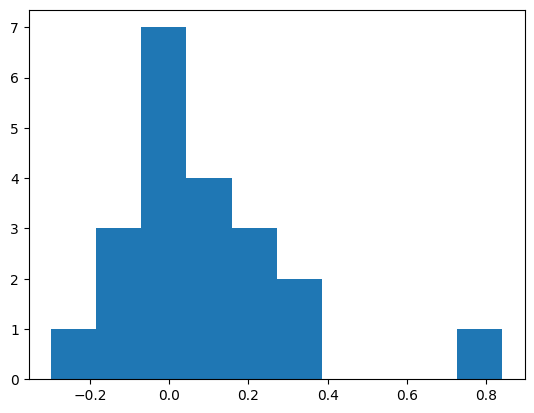

In [111]:
plt.hist(values)

In [112]:
# Loading the configuration to reconstruct the ansatz
with open(f"{path}/config.json") as f:
    config = json.load(f)

print(config)

{'nlayers': 2, 'b': 1.2566370614359172, 'theta': 1.5707963267948966, 'replacement_probability': 0.75, 'ncircuits': 20, 'random_seed': 42, 'local_pauli_noise_sigma': 0.003, 'max_bond_dimension': 128, 'nruns': 10, 'plot': True, 'save_results': True, 'nqubits': 21}


In [113]:
# detect training parameter files
path = Path(path)
param_files = sorted((path / "circuits").glob("params_circuit*.npy"))
# Load all the executed circuits' parameters
circuit_params = []
for p in param_files:
    print(p)
    circuit_params.append(np.load(p))

21q_2l/circuits/params_circuit0.npy
21q_2l/circuits/params_circuit1.npy
21q_2l/circuits/params_circuit10.npy
21q_2l/circuits/params_circuit11.npy
21q_2l/circuits/params_circuit12.npy
21q_2l/circuits/params_circuit13.npy
21q_2l/circuits/params_circuit14.npy
21q_2l/circuits/params_circuit15.npy
21q_2l/circuits/params_circuit16.npy
21q_2l/circuits/params_circuit17.npy
21q_2l/circuits/params_circuit18.npy
21q_2l/circuits/params_circuit19.npy
21q_2l/circuits/params_circuit2.npy
21q_2l/circuits/params_circuit3.npy
21q_2l/circuits/params_circuit4.npy
21q_2l/circuits/params_circuit5.npy
21q_2l/circuits/params_circuit6.npy
21q_2l/circuits/params_circuit7.npy
21q_2l/circuits/params_circuit8.npy
21q_2l/circuits/params_circuit9.npy


In [116]:
# Construct Floquet inspired ansatz and related transpiled one
floq_ansatz = FloquetAnsatz(
    nqubits=config["nqubits"],
    nlayers=1,
    b=config["b"],
    theta=config["theta"],
    target_qubit=int(config["nqubits"]/2)
)

print(floq_ansatz.circuit.summary())

Circuit depth = 22
Total number of gates = 282
Number of qubits = 21
Most common gates:
rz: 121
rx: 80
cx: 80
h: 1


In [102]:
# Construct observable
# Target qubit
q = int(config["nqubits"]/2)
obs = "I" * (q) + "X" + "I" * (config["nqubits"] - (q + 1))
print(obs)

IIIIIIIIIIXIIIIIIIII


In [ ]:
# Construct hybrid surrogate and test it
hs = HybridSurrogate(ansatz=floq_ansatz)

# repl_prob = 0. means we leave it as it is
expval, _  = hs.expectation_from_partition(
    observable=obs,
    replacement_probability=0.,
)

print(expval)

In [104]:
# Construct the symbolic form from the observable pauli operators
form = 1
for i, pauli in enumerate(obs):
    form *= getattr(symbols, pauli)(i)

# The correspondent hamiltonian
ham = hamiltonians.SymbolicHamiltonian(form)
# And execute expval as double check
ham.expectation(floq_ansatz.circuit().state())

np.float64(0.5164012882928387)

#### Compute exact expectation values using our simulator

In [105]:
exact_values = []
for i, par in enumerate(circuit_params[10:20]):
    # Update Floquet ansatz
    floq_ansatz.circuit.set_parameters(par)
    exact_val = ham.expectation(floq_ansatz.circuit().state())
    exact_values.append(exact_val)
    # tran_ansatz = TranspiledAnsatz(original_circuit=floq_ansatz.circuit)
    # # Construct surrogate
    # hs = HybridSurrogate(tran_ansatz)
    # # Compute expectation value
    # exact_val = hs.expectation_from_partition(observable=obs, replacement_probability=0.)[0]
    # exact_values.append(exact_val)
    print(f"Exact value for params {i+1}/20: {exact_val}, while noisy value is: {values[i+1]}")

Exact value for params 1/20: -0.00012458997675228732, while noisy value is: -0.0393623302499508
Exact value for params 2/20: -0.005960341186676511, while noisy value is: -0.013294762109927987
Exact value for params 3/20: 0.0033315912818623035, while noisy value is: 0.020265678097003397
Exact value for params 4/20: 0.020799367947705528, while noisy value is: -0.009885696632684585


SystemError: CPUDispatcher(<function apply_gate_kernel at 0x7f7f47875e40>) returned a result with an exception set

In [45]:
def line(x, a, b):
    """Linear ansatz"""
    return x * a + b

def plot_mitigation(exact_values, noisy_values, line_params=None):
    """Plot mitigation results"""
    plt.figure(figsize=(5, 5*6/8), dpi=100)
    plt.scatter(noisy_values, exact_values, color="purple", label="Data")
    if line_params is not None:
        x = np.linspace(min(noisy_values), max(noisy_values), 100)
        y = line(x, *line_params)
        plt.plot(x, y, color="black", label="Fit", ls="-")
    plt.xlabel("IBM hardware")
    plt.ylabel("Exact")
    plt.legend()
    plt.grid()

In [48]:
sorted_indices = natural_sort_indices(len(values) - 1)
print(sorted_indices)
noisy_values = np.array(values[1:])[sorted_indices]

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


In [86]:
for x, y in zip(noisy_values, exact_values):
    print(x, y)

-0.006911217437533227 0.4999999999999979
0.26164024466358754 0.9136271242968663
0.3312068048910154 0.9999999999999976
0.1235235895743979 0.5596821892578274
-0.07337512372154405 0.9136271242968665
0.839836492010405 0.9999999999999986
0.0894766112587283 0.9999999999999961
-0.017947871989442428 0.7141906864453
-0.11396011396011396 0.9045084971874708
-0.08240297713981924 0.9999999999999964
0.1884526558891455 0.9999999999999973
0.008973935994721214 0.4147165489775249
0.10086131569092498 0.9045084971874704
-0.003963830050786573 0.5477457514062619
-0.2977235235895744 0.9999999999999962
0.19267568459254372 0.37499999999999933
0.03345400074897017 0.9522542485937341
0.003695150115473441 0.9999999999999969
0.14632639189272695 0.33355506496095927
0.32577396032874 0.8658813728906035


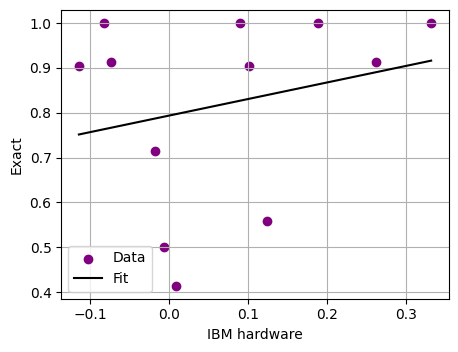

In [87]:
indices = [0,1,2,3,4,6,7,8,9,10,11,12]

noisy_values = np.array(noisy_values)[indices]
exact_values = np.array(exact_values)[indices]

# Adopt a linear map and fit the data
popt, pcov = curve_fit(line, noisy_values, exact_values)
popt

# Show the results in a plot
plot_mitigation(exact_values, noisy_values, popt)

In [88]:
values[0]

array(-0.03949398)

In [89]:
# Show the results in numbers
noisy_value = values[0]
exact_value = 0.55

print(f"Noisy: {noisy_value}")
print(f"Exact: {exact_value}")
print(f"Mitig: {line(noisy_value, *popt)}")
print(f"\nMSE noisy: {(noisy_value-exact_value)**2}")
print(f"MSE mitig: {(line(noisy_value, *popt)-exact_value)**2}")

Noisy: -0.03949398333847578
Exact: 0.55
Mitig: 0.7791781867610961

MSE noisy: 0.3475031563922632
MSE mitig: 0.05252264128710381


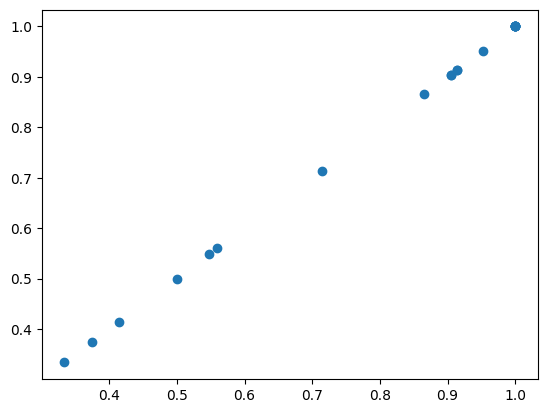

In [52]:
plt.scatter(exact_values, exact_values)